<a href="https://colab.research.google.com/github/NikhilGeorge01/DeepLearningPractice/blob/main/IntroToDL(Week1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F

In [18]:
class Model(nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.fc1 = nn.Linear(1,10)
    self.fc2 = nn.Linear(10,1)
  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x
model = Model()
print(model)

Model(
  (fc1): Linear(in_features=1, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)


In [11]:
model = Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

X = torch.randn(100, 1)
y = 3 * X + 1

for _ in range(200):
    optimizer.zero_grad()
    loss = ((model(X) - y) ** 2).mean()
    loss.backward()
    optimizer.step()

In [12]:
model.eval()
with torch.no_grad():
    test = torch.tensor([[5.0]])
    pred = model(test)
    print(pred)

tensor([[14.7526]])


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

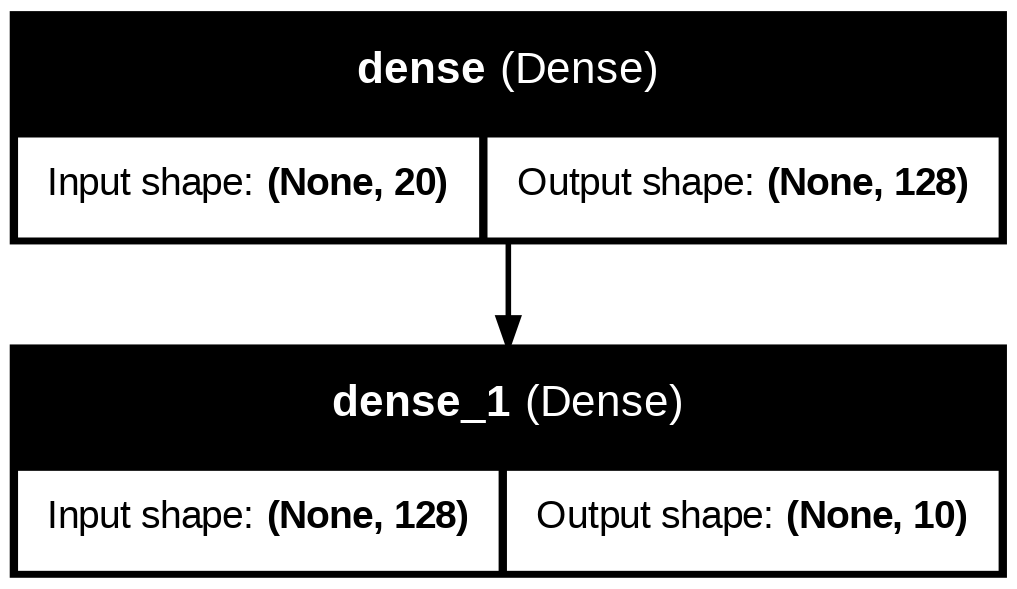

In [15]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

model = keras.Sequential([
    keras.Input(shape=(20,)),   # example: 20 features
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

plot_model(model, show_shapes=True, show_layer_names=True)

In [19]:
import numpy as np
class Perceptron:
    def __init__(self, n_features, lr=0.1):
        self.w = np.random.randn(n_features)
        self.b = np.random.randn()
        self.lr = lr
    def step(self, x):
        return 1 if x >= 0 else 0
    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        return np.array([self.step(x) for x in linear])
    def fit(self, X, y, epochs=100):
        for _ in range(epochs):
            for i in range(len(X)):
                linear = np.dot(X[i], self.w) + self.b
                y_pred = self.step(linear)
                error = y[i] - y_pred
                self.w += self.lr * error * X[i]
                self.b += self.lr * error

In [20]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])
p = Perceptron(n_features=2)
p.fit(X, y, epochs=100)
print(p.predict(X))

[0 0 0 1]
